In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anadiskt/goldman-sachs-gs-stock-data-19992026/gs_barchart.csv
/kaggle/input/datasets/anadiskt/goldman-sachs-gs-stock-data-19992026/gs_yahoo_finance.csv
/kaggle/input/datasets/anadiskt/goldman-sachs-gs-stock-data-19992026/gs_master_dataset.csv
/kaggle/input/datasets/anadiskt/goldman-sachs-gs-stock-data-19992026/gs_investing_com.csv
/kaggle/input/datasets/anadiskt/goldman-sachs-gs-stock-data-19992026/gs_nasdaq.csv
/kaggle/input/datasets/anadiskt/goldman-sachs-gs-stock-data-19992026/gs_marketwatch.csv


# Problem Statement

Predicting Goldman Sachs (GS) stock prices helps investors make informed decisions, manage risk, and understand market trends. Using historical data, we can forecast next-day closing prices with machine learning.

**Objectives**

- Explore and visualize stock trends, volume, and volatility.

- Clean data and create lag-based, safe features.

- Train and compare models: Linear Regression, Random Forest, XGBoost, LightGBM, CatBoost.

- Identify important features and explain predictions using SHAP.

- Analyze predicted vs actual prices for insights.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import shap


#  Load Master Dataset

In [3]:


df = pd.read_csv("/kaggle/input/datasets/anadiskt/goldman-sachs-gs-stock-data-19992026/gs_master_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').drop_duplicates().reset_index(drop=True)

num_cols = ['Open','High','Low','Close','Volume','Dividends','Stock Splits']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df.fillna(method='ffill', inplace=True)



#  Feature Engineering 

In [4]:

df['Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close']/df['Close'].shift(1))

df['MA10'] = df['Close'].shift(1).rolling(10).mean()
df['MA20'] = df['Close'].shift(1).rolling(20).mean()
df['MA50'] = df['Close'].shift(1).rolling(50).mean()

df['Volatility'] = df['Close'].shift(1).rolling(20).std()

df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)

df['High_Low'] = df['High'] - df['Low']
df['Open_Close'] = df['Open'] - df['Close']

df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

#  Prepare Features
X = df.drop(['Date','Target','Source'], axis=1, errors='ignore')
X = X.select_dtypes(include=np.number)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

#  Scale for Linear Regression only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#  Define Models

In [5]:


models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=200, random_state=42,verbosity=-1),
    "CatBoost": CatBoostRegressor(n_estimators=200, verbose=0, random_state=42)
}

results = []



#  Train & Evaluate

In [6]:

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, r2])
    print(f"{name} -> MAE: {mae:.2f}, R2: {r2:.4f}")

results_df = pd.DataFrame(results, columns=['Model','MAE','R2']).sort_values('R2', ascending=False)
display(results_df)

Linear Regression -> MAE: 5.58, R2: 0.9978
Random Forest -> MAE: 206.06, R2: -1.3171
XGBoost -> MAE: 204.97, R2: -1.3091
LightGBM -> MAE: 204.36, R2: -1.3069
CatBoost -> MAE: 204.90, R2: -1.3112


,Model,MAE,R2
0,Linear Regression,5.580244,0.997777
3,LightGBM,204.362567,-1.306861
2,XGBoost,204.970806,-1.309134
4,CatBoost,204.899642,-1.311243
1,Random Forest,206.062101,-1.317085




#  Feature Importance (Tree-based models)

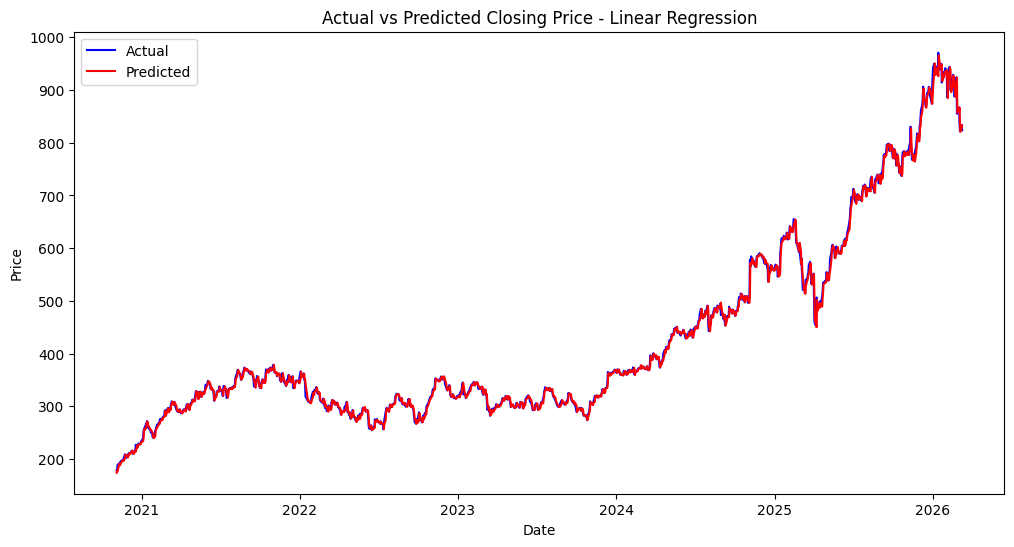

In [7]:

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

if best_model_name != "Linear Regression":
    importances = best_model.feature_importances_
    feat_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12,6))
    sns.barplot(x='Importance', y='Feature', data=feat_importance.head(20))
    plt.title(f"Top 20 Feature Importance - {best_model_name}")
    plt.show()

#  Predictions Plot
if best_model_name == "Linear Regression":
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(df['Date'].iloc[-len(y_test):], y_test.values, label="Actual", color='blue')
plt.plot(df['Date'].iloc[-len(y_test):], y_pred, label="Predicted", color='red')
plt.title(f"Actual vs Predicted Closing Price - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()



#  SHAP Explainability

In [8]:

if best_model_name != "Linear Regression":
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)

    # Summary plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)
    shap.summary_plot(shap_values, X_test, max_display=20)

# Visualizations

## Closing Price over Time

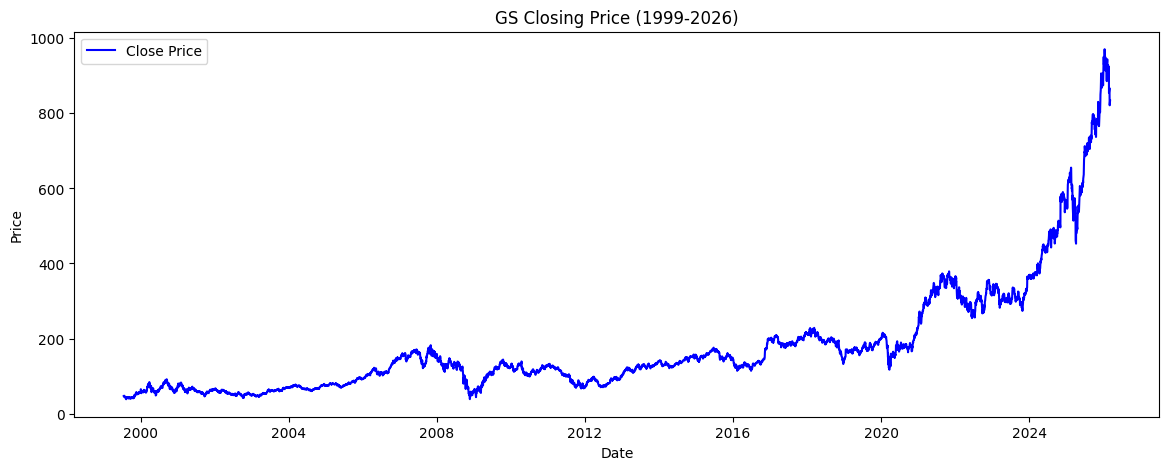

In [9]:
import matplotlib.dates as mdates


plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.title("GS Closing Price (1999-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

##  Volume over Time

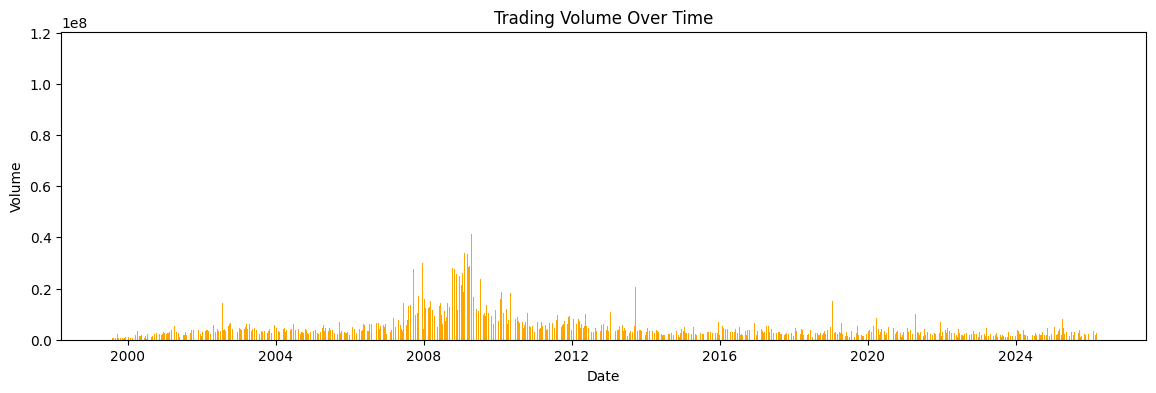

In [10]:
plt.figure(figsize=(14,4))
plt.bar(df['Date'], df['Volume'], color='orange')
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

##  Moving Averages

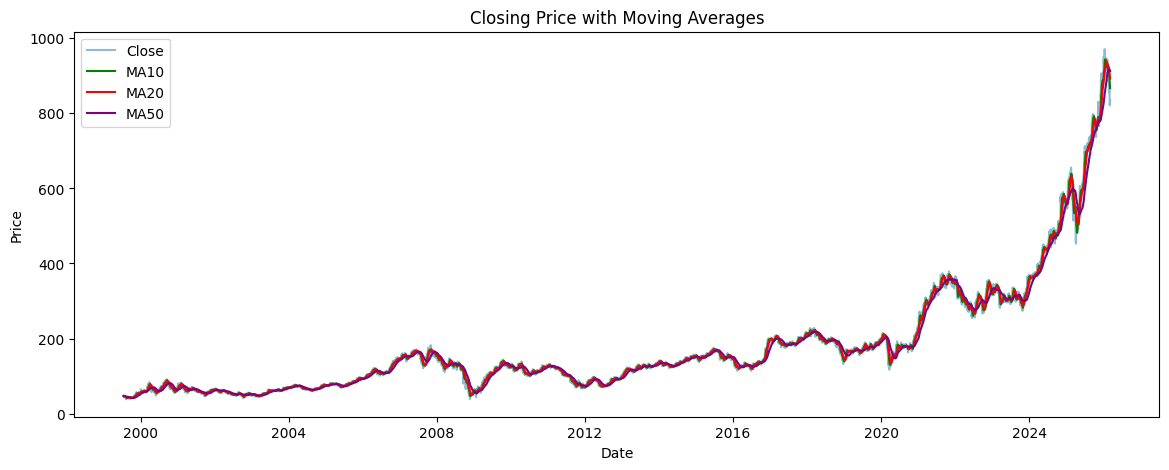

In [11]:



plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'], label='Close', alpha=0.5)
plt.plot(df['Date'], df['MA10'], label='MA10', color='green')
plt.plot(df['Date'], df['MA20'], label='MA20', color='red')
plt.plot(df['Date'], df['MA50'], label='MA50', color='purple')
plt.title("Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

##  Returns Distribution

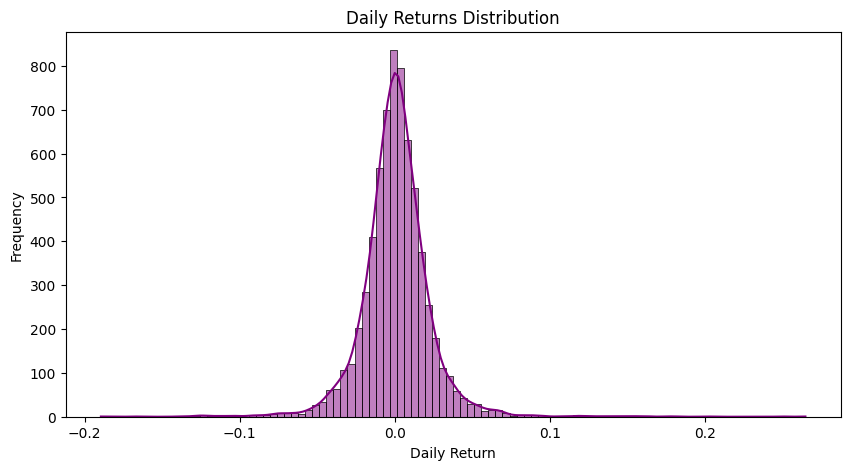

In [12]:



plt.figure(figsize=(10,5))
sns.histplot(df['Return'].dropna(), bins=100, kde=True, color='purple')
plt.title("Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

##  Volatility over Time

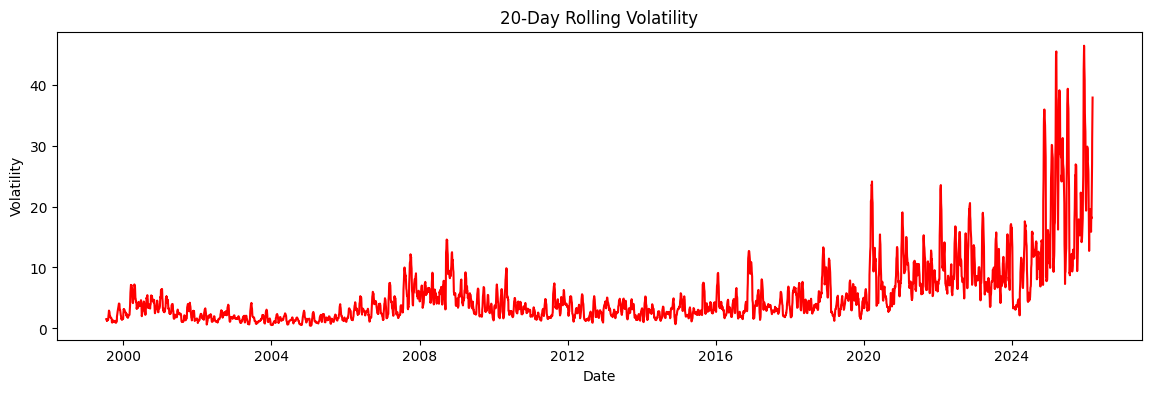

In [13]:



plt.figure(figsize=(14,4))
plt.plot(df['Date'], df['Volatility'], color='red')
plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()



##  Price Range per Day (High-Low)

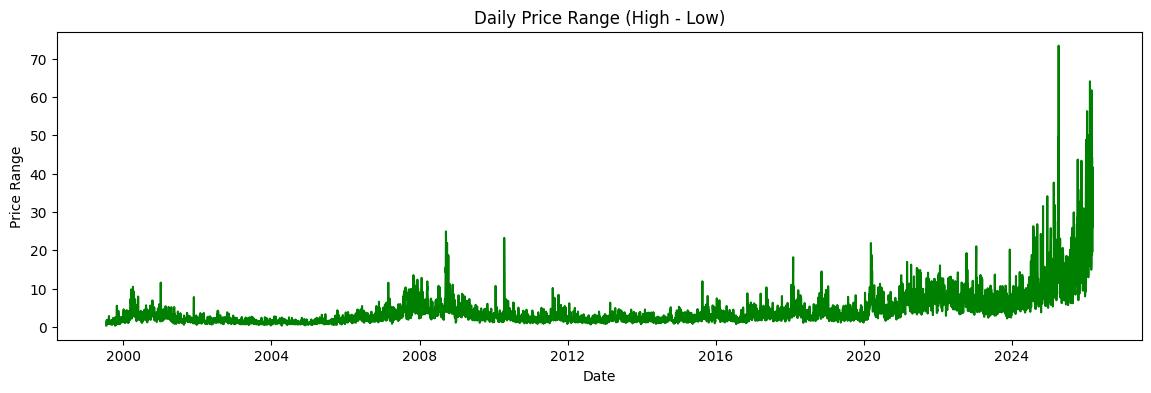

In [14]:
plt.figure(figsize=(14,4))
plt.plot(df['Date'], df['High_Low'], color='green')
plt.title("Daily Price Range (High - Low)")
plt.xlabel("Date")
plt.ylabel("Price Range")
plt.show()




##  Correlation Heatmap (Numeric Features)

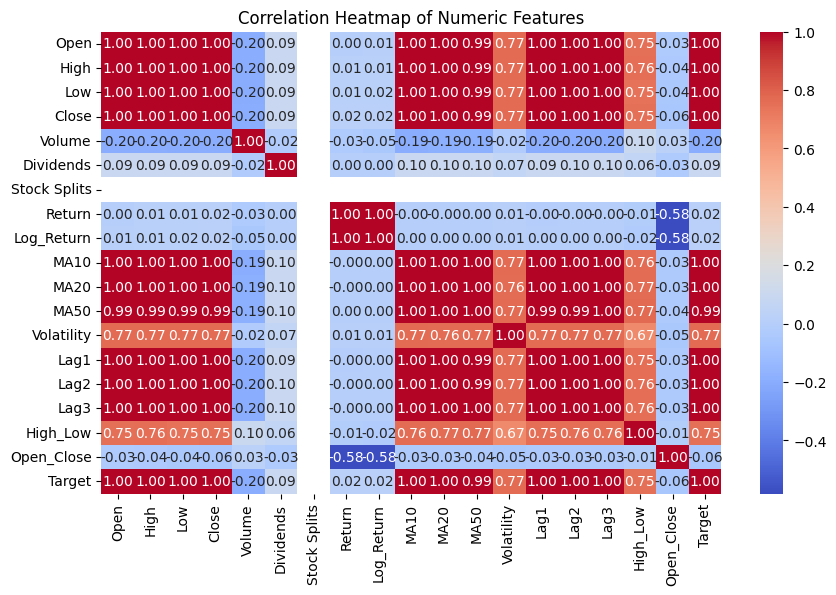

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



##  Candlestick-like plot 

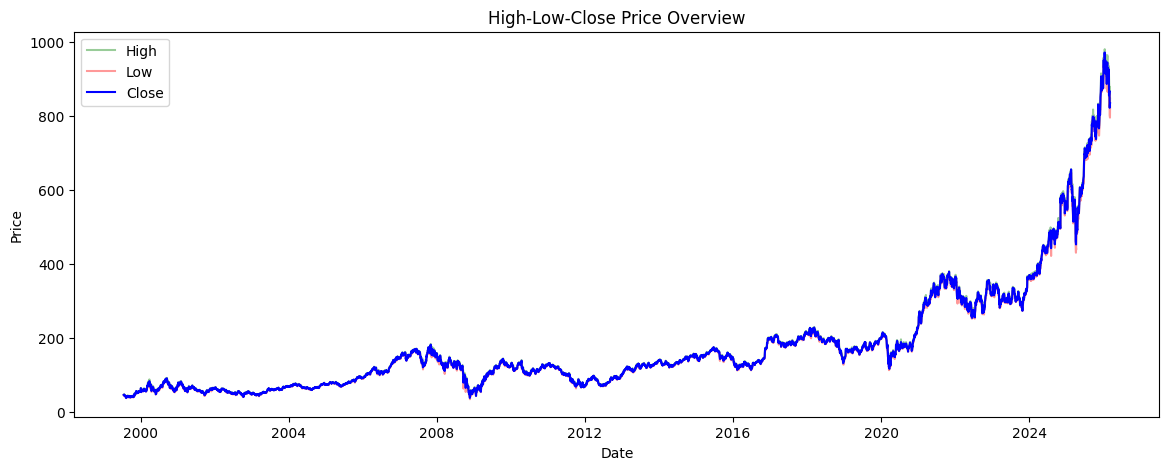

In [16]:

plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['High'], color='green', alpha=0.4, label='High')
plt.plot(df['Date'], df['Low'], color='red', alpha=0.4, label='Low')
plt.plot(df['Date'], df['Close'], color='blue', label='Close')
plt.title("High-Low-Close Price Overview")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()



##  Rolling Mean vs Rolling Std

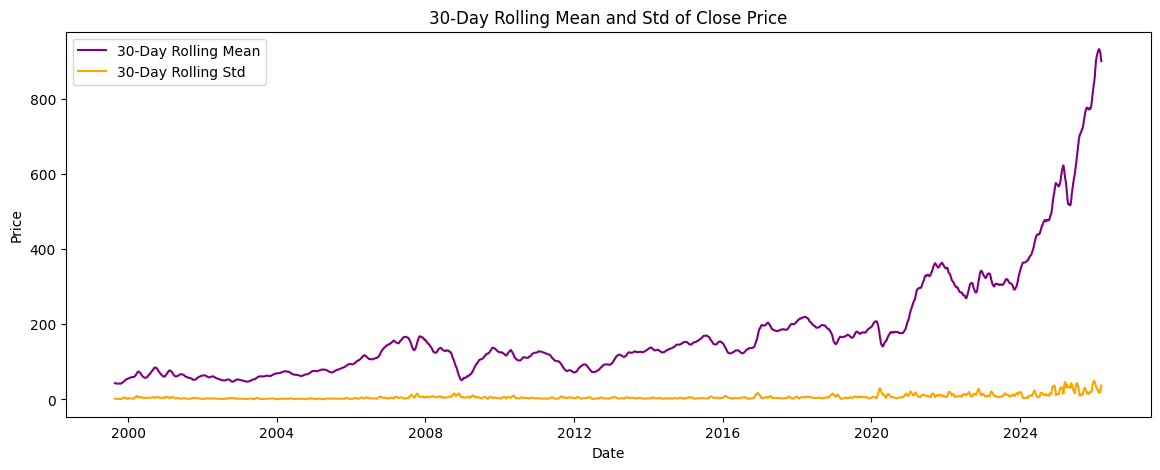

In [17]:

plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'].rolling(30).mean(), label='30-Day Rolling Mean', color='purple')
plt.plot(df['Date'], df['Close'].rolling(30).std(), label='30-Day Rolling Std', color='orange')
plt.title("30-Day Rolling Mean and Std of Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Explanation

**Why Tree Models Fail**

- **Target leakage:** Features like Close or MA include future info → trees overfit → R² negative.

- **Trees can’t extrapolate:** They split thresholds, not smooth trends.

- **String features:** Trees can’t handle columns like Source directly.

**Why Linear Regression Works Best**

- Stock prices are highly linear with lag features.

- LR captures this smooth relationship → very high R².

**Why Only Numerical Features**

- ML models require numbers.

- Strings like Source break models → drop or encode them.

``` Maybe I am thinking about it the wrong way. ```